In [23]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D)
import pickle

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from regressor import ExpPerceptronRegressor, PolynomialRegressor

In [24]:
SMALL_SIZE = 18
MEDIUM_SIZE = 24
BIGGER_SIZE = 24
plt.rc('font', size=SMALL_SIZE, family = "Nimbus Roman")          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
# plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [30]:
# Load mixing ratios and metrics

# for jan 21 analysis.
# this experiments used the "block structure" where the base and augmentation groups are the same size.
# exp_name = three_groups
# ps_key = "ps"
# metrics_key = "metrics"

exp_name = "expected_coef_filter_groups_partial_aug_test_all"

# exp_name = "stability"

ps_key = "validation ps"
metrics_key = "validation metrics"

filename = f"../results/mixing_results_by_group_{exp_name}.pickle"

with open(filename, "rb") as pickleFile:
    mixing_results_by_group = pickle.load(pickleFile)

for label in mixing_results_by_group:
    assert len(mixing_results_by_group[label][ps_key]) == len(mixing_results_by_group[label][metrics_key])
    print(f"{label}: {len(mixing_results_by_group[label][ps_key])} trials")
    
    ps = mixing_results_by_group[label][ps_key]
    group_labels = set(ps[0].keys())
    assert np.all([group_labels == set(p.keys()) for p in ps])
    
    metric_dicts = mixing_results_by_group[label][metrics_key]
    metric_names = set(metric_dicts[0].keys())
    assert np.all([metric_names == set(metric_dict.keys()) for metric_dict in metric_dicts])

18: 1000 trials
25: 1000 trials
35: 1000 trials


## Analyzing Best Mixing Ratios

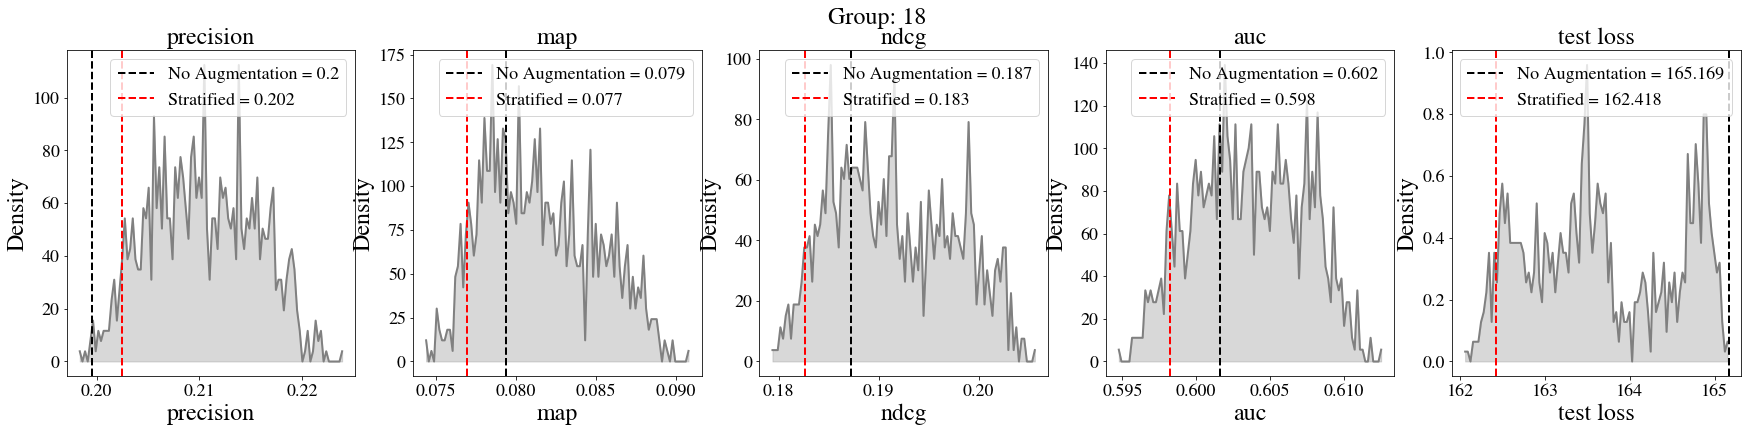

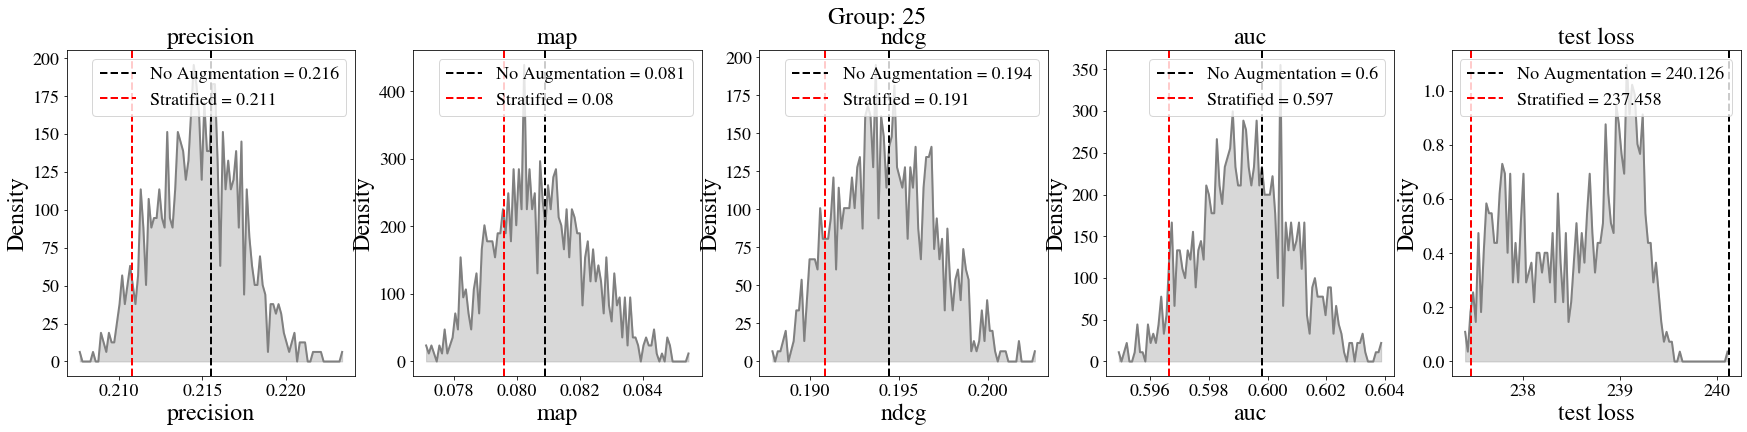

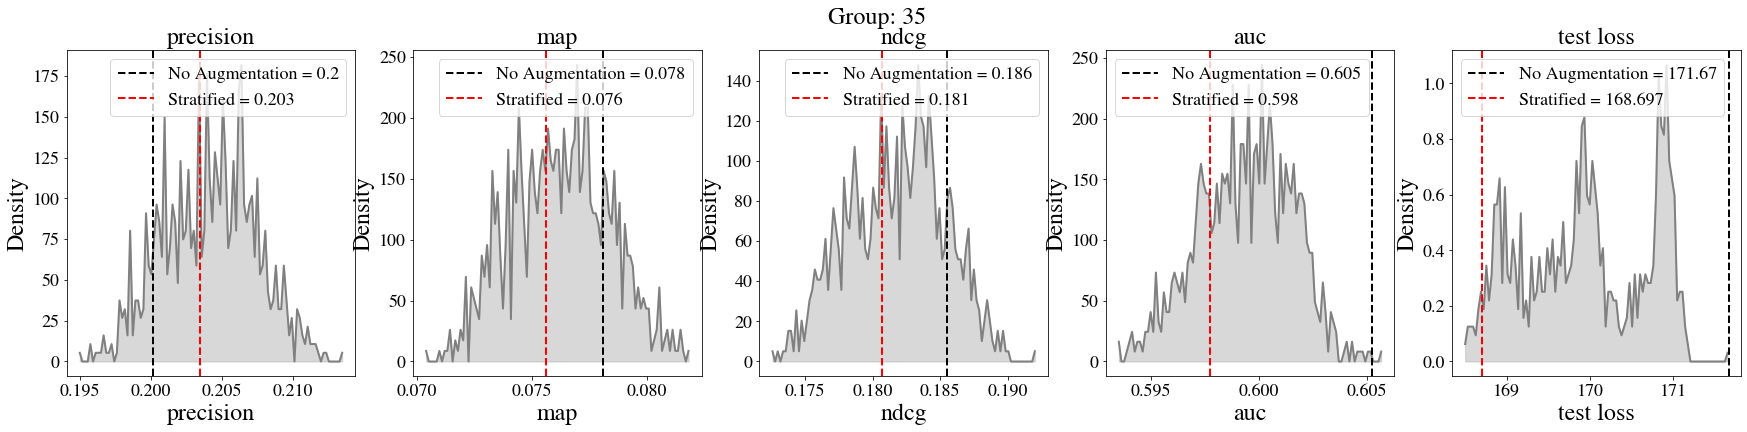

In [31]:
colors = ["black", "red"]
def plot_density_with_baseline(values, baseline_tuples, value_name="Values", title="Density Plot", ax=None):
    """
    Pure Matplotlib density plot with a vertical dashed baseline line.
    """
    values = np.asarray(values)

    # Compute histogram-based density estimate
    density, bins = np.histogram(values, bins=100, density=True)
    centers = 0.5 * (bins[:-1] + bins[1:])

    if ax == None:
        fig, ax = plt.subplots()

    ax.plot(centers, density, linewidth=2, color="gray")
    ax.fill_between(centers, density, alpha=0.3, color="gray")

    for baseline_idx, (baseline_name, baseline_val) in enumerate(baseline_tuples):
        ax.axvline(baseline_val, 
                   color=colors[baseline_idx],
                   linestyle="--", linewidth=2, 
                   label=f"{baseline_name} = {round(baseline_val, 3)}")

    ax.set_title(title)
    ax.set_xlabel(value_name)
    ax.set_ylabel("Density")
    ax.legend()

for label in mixing_results_by_group:
    metric_names = list(mixing_results_by_group[label][metrics_key][0].keys())
    metric_dicts = mixing_results_by_group[label][metrics_key]
    
    fig, axs = plt.subplots(ncols=len(metric_names), figsize=(6*len(metric_names), 6))
    fig.suptitle(f"Group: {label}")
    for metric_idx, metric_name in enumerate(metric_names):
        metric_vals = [metric_dict[metric_name] for metric_dict in metric_dicts]
        plot_density_with_baseline(metric_vals,
                                  [("No Augmentation", metric_vals[0]), ("Stratified", metric_vals[1])],
                                  value_name=metric_name,
                                  title=metric_name,
                                  ax=axs[metric_idx])


In [32]:
metric_name = "test loss"

for label in mixing_results_by_group:
    print(label)
    metric_dicts = mixing_results_by_group[label][metrics_key]
    
    ps = mixing_results_by_group[label][ps_key]
    group_labels = set(ps[0].keys())
    
    test_losses = [metric_dict[metric_name] for metric_dict in metric_dicts]
    idxs_sorted = np.argsort(test_losses)
    
    for idx in idxs_sorted[:10]:
        p = ps[idx]
        loss = test_losses[idx]
        
        rounded_p = {label: round(p[label], 2) for label in group_labels}
        print(f"{round(loss, 3)} \t {rounded_p}")
    print('\n')

18
162.04 	 {'18': 0.0, '25': 0.57, '35': 0.43}
162.097 	 {'18': 0.0, '25': 0.58, '35': 0.42}
162.14 	 {'18': 0.0, '25': 0.59, '35': 0.41}
162.159 	 {'18': 0.0, '25': 0.67, '35': 0.33}
162.168 	 {'18': 0.0, '25': 0.67, '35': 0.33}
162.176 	 {'18': 0.0, '25': 0.71, '35': 0.29}
162.198 	 {'18': 0.0, '25': 0.56, '35': 0.44}
162.219 	 {'18': 0.0, '25': 0.61, '35': 0.39}
162.237 	 {'18': 0.0, '25': 0.7, '35': 0.3}
162.243 	 {'18': 0.0, '25': 0.59, '35': 0.41}


25
237.388 	 {'18': 0.51, '25': 0.0, '35': 0.49}
237.401 	 {'18': 0.54, '25': 0.0, '35': 0.46}
237.413 	 {'18': 0.48, '25': 0.0, '35': 0.52}
237.438 	 {'18': 0.59, '25': 0.0, '35': 0.41}
237.453 	 {'18': 0.53, '25': 0.0, '35': 0.47}
237.458 	 {'18': 0.51, '25': 0.0, '35': 0.49}
237.458 	 {'18': 0.48, '25': 0.0, '35': 0.52}
237.463 	 {'18': 0.51, '25': 0.0, '35': 0.49}
237.467 	 {'18': 0.56, '25': 0.0, '35': 0.44}
237.473 	 {'18': 0.45, '25': 0.0, '35': 0.55}


35
168.482 	 {'18': 0.32, '25': 0.68, '35': 0.0}
168.505 	 {'18': 0.36, '2

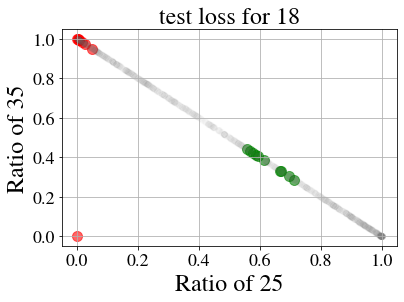

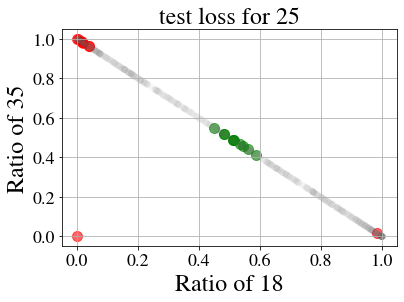

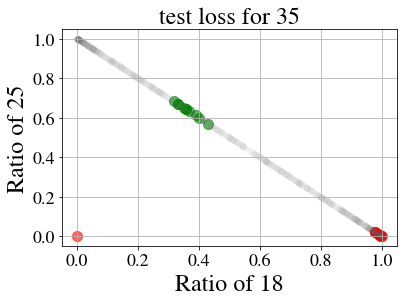

In [33]:
## Parameters
metric_name = "test loss"

labels = [
    ("18", "25", "35"),
    ("25", "18", "35"),
    ("35", "18", "25")
]

top_k = 10

for base_label, x_label, y_label in labels:
    metric_dicts = np.array(mixing_results_by_group[base_label][metrics_key])
    ps = np.array(mixing_results_by_group[base_label][ps_key])

    test_losses = [metric_dict[metric_name] for metric_dict in metric_dicts]
    idxs_sorted = np.argsort(test_losses)

    fig, ax = plt.subplots()

    ax.scatter(
        x = [p[x_label] for p in ps[idxs_sorted[:top_k]]],
        y = [p[y_label] for p in ps[idxs_sorted[:top_k]]],
        color="green",
        s=100,
        alpha=0.6
    )

    ax.scatter(
        x = [p[x_label] for p in ps[idxs_sorted[-top_k:]]],
        y = [p[y_label] for p in ps[idxs_sorted[-top_k:]]],
        color="red",
        s=100,
        alpha=0.6
    )
    
    ax.scatter(
        x = [p[x_label] for p in ps[idxs_sorted[top_k:-top_k]]],
        y = [p[y_label] for p in ps[idxs_sorted[top_k:-top_k]]],
        color="gray",
        alpha=0.02
    )

    ax.set_xlabel(f"Ratio of {x_label}")
    ax.set_ylabel(f"Ratio of {y_label}")
    ax.set_title(f"{metric_name} for {base_label}")
    ax.grid()

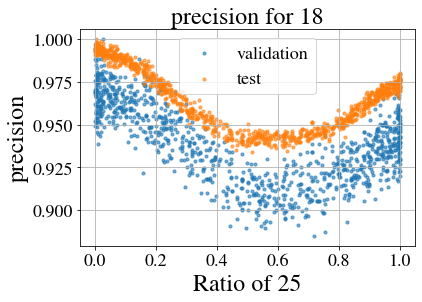

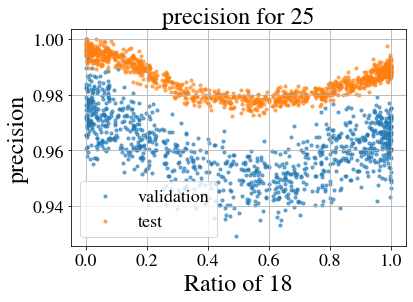

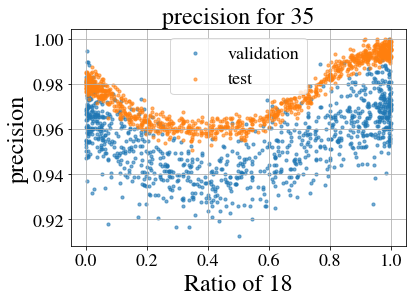

In [34]:
## Parameters
metric_name = "precision"

labels = [
    ("18", "25", "35"),
    ("25", "18", "35"),
    ("35", "18", "25")
]

for base_label, x_label, y_label in labels:
    ps_validation = np.array(mixing_results_by_group[base_label]["validation ps"])[1:]
    metric_dicts_validation = np.array(mixing_results_by_group[base_label]["validation metrics"])[1:]
    
    ps_test = np.array(mixing_results_by_group[base_label]["test ps"])[2:]
    metric_dicts_test = np.array(mixing_results_by_group[base_label]["test metrics"])[2:]
    

    validation_losses = np.array([metric_dict[metric_name] for metric_dict in metric_dicts_validation])
    test_losses = np.array([metric_dict[metric_name] for metric_dict in metric_dicts_test])

    fig, ax = plt.subplots()

    ax.scatter(
        x = [p[x_label] for p in ps_validation],
        y = validation_losses / np.max(validation_losses),
        s=10,
        alpha=0.6,
        label="validation"
    )
    
    ax.scatter(
        x = [p[x_label] for p in ps_test],
        y = test_losses / np.max(test_losses),
        s=10,
        alpha=0.6,
        label="test"
    )
    
    
    ax.legend()

    ax.set_xlabel(f"Ratio of {x_label}")
    ax.set_ylabel(f"{metric_name}")
    ax.set_title(f"{metric_name} for {base_label}")
    ax.grid()

## Regression on Mixing Ratios

In [17]:
from sklearn.linear_model import LinearRegression
import math

def f(x):
    return math.sqrt(x)

base_label = "35"
ps = mixing_results_by_group[base_label]["ps"]
metrics = mixing_results_by_group[base_label]["metrics"]

metric_name = "test loss"
metric_values = np.array([metric_dict[metric_name] for metric_dict in metrics])

p_vec = np.array([[f(p[label]) for label in group_labels if label != base_label] for p in ps])
coef_names = [label for label in group_labels if label != base_label]

model = LinearRegression()
model.fit(p_vec, metric_values)

r2 = model.score(p_vec, metric_values)
print(r2)


coefs = model.coef_
for label, coef in zip(coef_names, coefs):
    print(f"{label}: {coef}")

print(model.intercept_)

KeyError: 'ps'

epoch     1/1000 | loss=0.0448563 | ||W||=0.02646
epoch  1000/1000 | loss=2.97181e-06 | ||W||=0.1731
Train R2: 0.25921342603238506
epoch     1/1000 | loss=0.0463585 | ||W||=0.02646
epoch  1000/1000 | loss=3.06565e-06 | ||W||=0.1805
Train R2: -1.7029300232760423
epoch     1/1000 | loss=0.0415011 | ||W||=0.02646
epoch  1000/1000 | loss=5.12821e-06 | ||W||=0.171
Train R2: -0.6285110453000406


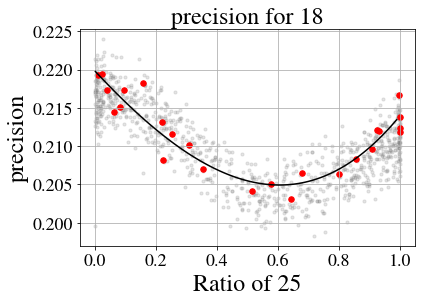

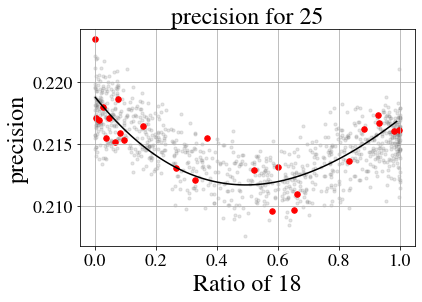

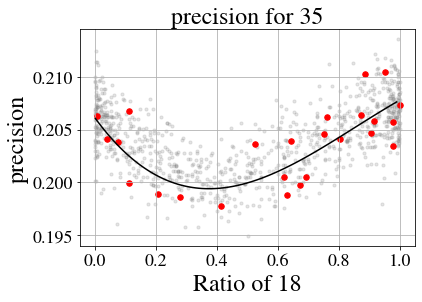

In [13]:
## Parameters
metric_name = "precision"
num_training_ratios = 25

labels = [
    ("18", "25", "35"),
    ("25", "18", "35"),
    ("35", "18", "25")
]

for base_label, x_label, y_label in labels:
    ps_validation = np.array(mixing_results_by_group[base_label]["validation ps"])
    metric_dicts_validation = np.array(mixing_results_by_group[base_label]["validation metrics"])

    group_labels = [base_label, x_label, y_label]
    P = np.array([
        [p[aug_label] for aug_label in group_labels]
        for p in ps_validation
    ])
        
    y = np.array([metric_dict[metric_name] for metric_dict in metric_dicts_validation])

    rng = np.random.default_rng()
    training_idx = rng.choice(len(y), size=num_training_ratios, replace=False)
    
    model = PolynomialRegressor(dim=len(group_labels), degree=3, seed=0)
    model.fit(P[training_idx], y[training_idx], epochs=1000, verbose_every=1000, loss="mse")
    print("Train R2:", model.r2(P, y))

    fig, ax = plt.subplots()

    ax.scatter(
        x = [p[x_label] for p in ps_validation],
        y = y,
        s=10,
        alpha=0.2,
        color="grey",
        label="all ratios"
    )

    ax.scatter(
        x = [p[x_label] for p in ps_validation[training_idx]],
        y = y[training_idx],
        s=30,
        alpha=1.0,
        color="red",
        label="training ratios"
    )
    
    regression_x = np.arange(0, 1.0, 0.01)
    test_P = np.array([[0, x, 1-x] for x in regression_x])
    regression_y = model.predict(test_P)
    ax.plot(
        regression_x,
        regression_y,
        color="black",
        label="regression"
    )
    
    ax.set_xlabel(f"Ratio of {x_label}")
    ax.set_ylabel(f"{metric_name}")
    ax.set_title(f"{metric_name} for {base_label}")
    ax.grid()